In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [60]:
data = pd.read_csv("diabetes2.csv")
df = data.copy()

In [61]:
df.head(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


<Axes: >

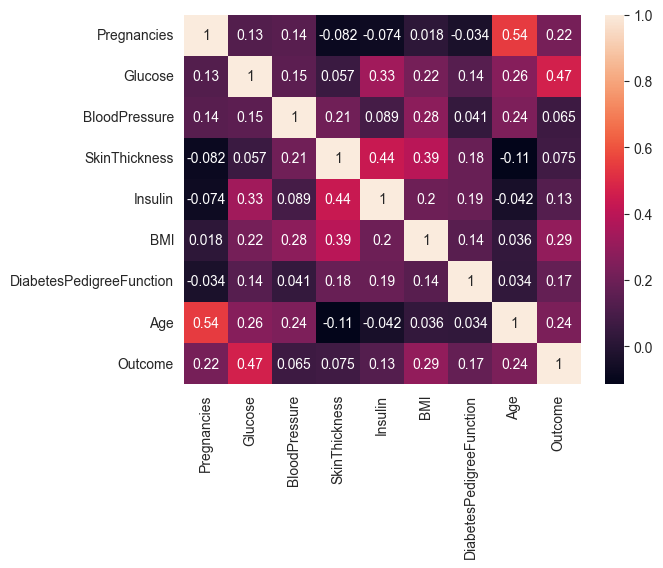

In [62]:
data_corr = df.corr()
sns.heatmap(data_corr, annot=True)

<Axes: >

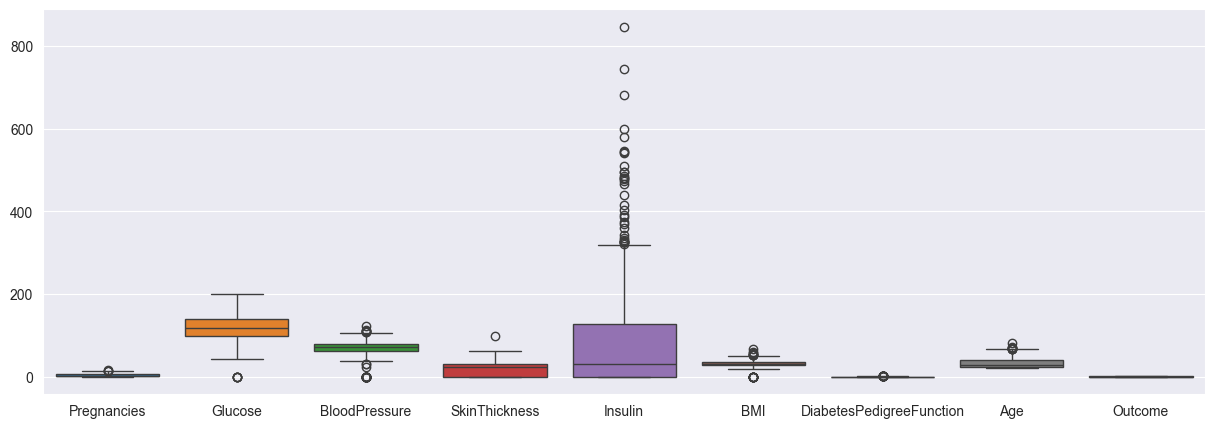

In [63]:
plt.figure(figsize=(15,5))
sns.boxplot(data)

In [64]:
df.query('Insulin == 0')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [65]:
# insulin_median = df[df['Insulin'] > 0]['Insulin'].median()

In [66]:
# df['Insulin'] = df['Insulin'].replace(0,insulin_median)

In [67]:
# df['Glucose'] = df['Glucose'].replace(0, df[df['Glucose'] > 0]['Glucose'].median())
# df['BMI'] = df['BMI'].replace(0, df[df['BMI'] > 0]['BMI'].median())
# df['BloodPressure'] = df['BloodPressure'].replace(0, df[df['BloodPressure'] > 0]['BloodPressure'].median())

In [68]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zeros:
    median = df[df[col] > 0][col].median()
    df[col] = df[col].replace(0, median)

<Axes: >

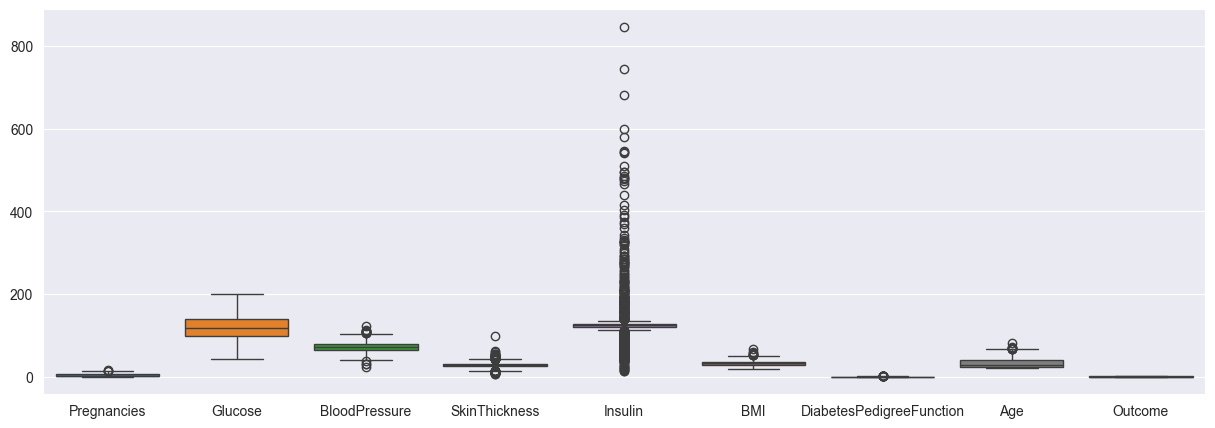

In [69]:
plt.figure(figsize=(15,5))
sns.boxplot(df)

In [70]:
scaler = RobustScaler()

X = df.drop('Outcome', axis=1)
y = df['Outcome']

<Axes: >

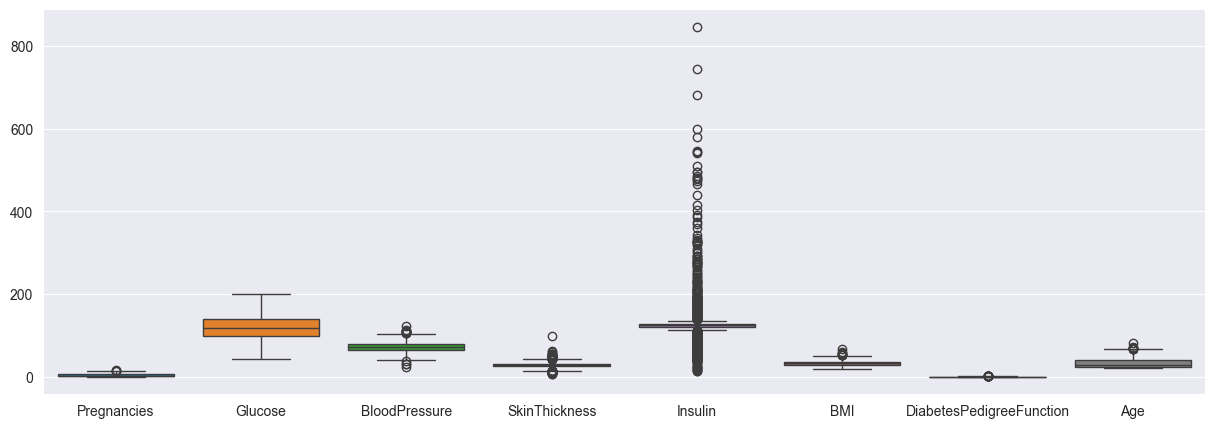

In [71]:
plt.figure(figsize=(15,5))
sns.boxplot(X)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76        99
           1       0.57      0.71      0.63        55

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154



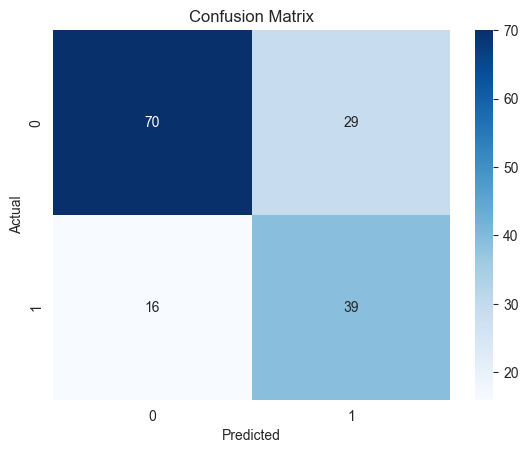

In [77]:
#model = LogisticRegression()
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Classification Report:")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
print(importance.sort_values(by='Importance', ascending=False))

                    Feature  Importance
1                   Glucose    1.448771
5                       BMI    0.910138
7                       Age    0.608470
0               Pregnancies    0.355622
6  DiabetesPedigreeFunction    0.262831
3             SkinThickness    0.075788
4                   Insulin   -0.019330
2             BloodPressure   -0.213370
